<a href="https://colab.research.google.com/github/melia1702/pertemuan-kesebelas/blob/main/Praktikum_11_1_MG_11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

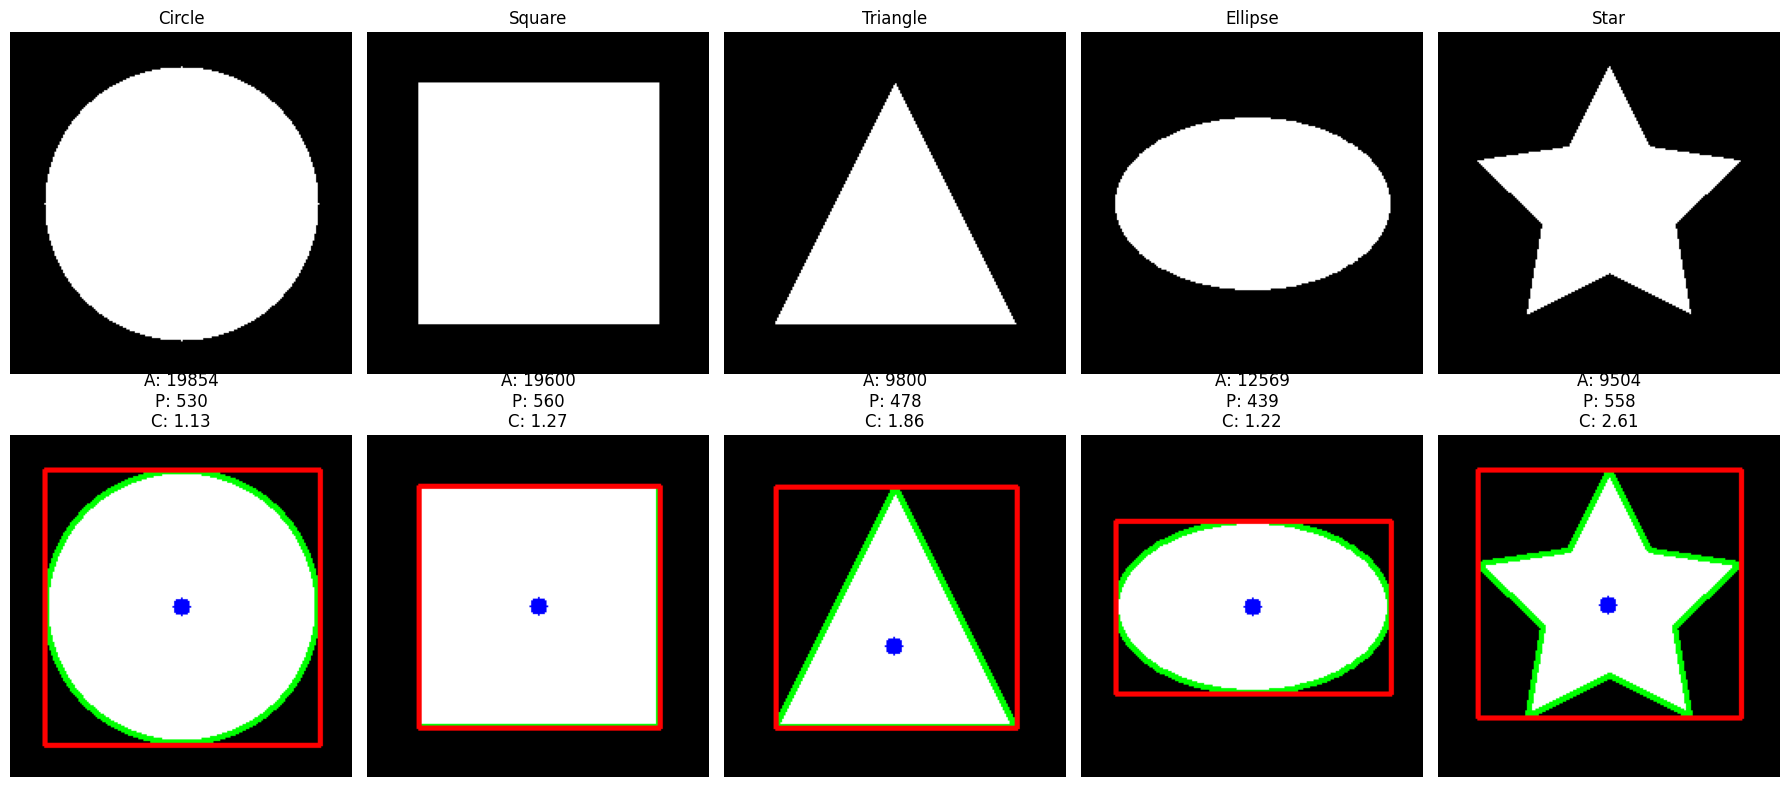

COMPREHENSIVE SHAPE ANALYSIS
Shape      Area     Perimeter  Compactness  Aspect Ratio Extent     Equi Diameter  
------------------------------------------------------------------------------------------
Circle     19854    530        1.13         1.00         0.77       159.0          
Square     19600    560        1.27         1.00         0.99       158.0          
Triangle   9800     478        1.86         1.00         0.49       111.7          
Ellipse    12569    439        1.22         1.59         0.77       126.5          
Star       9504     558        2.61         1.06         0.43       110.0          

HU MOMENTS ANALYSIS (log scale, invariant to rotation, scale, translation)
Shape      Hu1          Hu2          Hu3          Hu4         
--------------------------------------------------------------------------------
Circle     0.80         0.00         10.00        10.00       
Square     0.78         0.00         10.00        10.00       
Triangle   0.71         3.11  

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import distance

def latihan_1():
    # Buat berbagai bentuk geometris untuk analisis
    shapes = []
    shape_names = []

    # 1. Lingkaran (perfect circle)
    circle = np.zeros((200, 200), dtype=np.uint8)
    cv2.circle(circle, (100, 100), 80, 255, -1)
    shapes.append(circle)
    shape_names.append("Circle")

    # 2. Persegi (square)
    square = np.zeros((200, 200), dtype=np.uint8)
    cv2.rectangle(square, (30, 30), (170, 170), 255, -1)
    shapes.append(square)
    shape_names.append("Square")

    # 3. Segitiga (triangle)
    triangle = np.zeros((200, 200), dtype=np.uint8)
    pts = np.array([[100, 30], [30, 170], [170, 170]])
    cv2.fillPoly(triangle, [pts], 255)
    shapes.append(triangle)
    shape_names.append("Triangle")

    # 4. Elips (ellipse)
    ellipse = np.zeros((200, 200), dtype=np.uint8)
    cv2.ellipse(ellipse, (100, 100), (80, 50), 0, 0, 360, 255, -1)
    shapes.append(ellipse)
    shape_names.append("Ellipse")

    # 5. Bintang (star - complex shape)
    star = np.zeros((200, 200), dtype=np.uint8)
    points = []
    for i in range(10):
        angle = i * 2 * np.pi / 10
        radius = 80 if i % 2 == 0 else 40
        x = 100 + radius * np.cos(angle - np.pi/2)
        y = 100 + radius * np.sin(angle - np.pi/2)
        points.append([x, y])
    pts = np.array(points, dtype=np.int32)
    cv2.fillPoly(star, [pts], 255)
    shapes.append(star)
    shape_names.append("Star")

    # Analisis setiap bentuk
    shape_data = []

    fig, axes = plt.subplots(2, 5, figsize=(18, 8))

    for i, (shape, name) in enumerate(zip(shapes, shape_names)):
        # Temukan contours
        contours, _ = cv2.findContours(shape, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
        contour = contours[0]

        # 1. Basic region properties
        area = cv2.contourArea(contour)
        perimeter = cv2.arcLength(contour, True)

        # 2. Moments calculation
        M = cv2.moments(contour)

        # Centroid dari moments
        if M["m00"] != 0:
            cx = int(M["m10"] / M["m00"])
            cy = int(M["m01"] / M["m00"])
        else:
            cx, cy = 0, 0

        # 3. Bounding box properties
        x, y, w, h = cv2.boundingRect(contour)

        # 4. Hu moments (7 invariant moments)
        hu_moments = cv2.HuMoments(M).flatten()

        # 5. Shape descriptors
        compactness = (perimeter ** 2) / (4 * np.pi * area) if area > 0 else float('inf')
        aspect_ratio = w / h if h > 0 else 0

        # Equivalent diameter
        equi_diameter = np.sqrt(4 * area / np.pi)

        # Extent (ratio of contour area to bounding rectangle area)
        rect_area = w * h
        extent = area / rect_area if rect_area > 0 else 0

        # Simpan data
        shape_info = {
            'name': name,
            'area': area,
            'perimeter': perimeter,
            'centroid': (cx, cy),
            'compactness': compactness,
            'aspect_ratio': aspect_ratio,
            'extent': extent,
            'equi_diameter': equi_diameter,
            'hu_moments': hu_moments
        }
        shape_data.append(shape_info)

        # Visualisasi bentuk dengan annotations
        display_img = cv2.cvtColor(shape, cv2.COLOR_GRAY2BGR)

        # Draw contour
        cv2.drawContours(display_img, [contour], -1, (0, 255, 0), 2)

        # Draw centroid
        cv2.circle(display_img, (cx, cy), 5, (255, 0, 0), -1)

        # Draw bounding box
        cv2.rectangle(display_img, (x, y), (x + w, y + h), (0, 0, 255), 2)

        # Row 0: Original shapes
        axes[0, i].imshow(shape, cmap='gray')
        axes[0, i].set_title(name)
        axes[0, i].axis('off')

        # Row 1: Annotated shapes
        axes[1, i].imshow(cv2.cvtColor(display_img, cv2.COLOR_BGR2RGB))
        title = f'A: {area:.0f}\nP: {perimeter:.0f}\nC: {compactness:.2f}'
        axes[1, i].set_title(title)
        axes[1, i].axis('off')

    plt.tight_layout()
    plt.show()

    # Display comprehensive analysis table
    print("COMPREHENSIVE SHAPE ANALYSIS")
    print("=" * 90)
    print(f"{'Shape':<10} {'Area':<8} {'Perimeter':<10} {'Compactness':<12} {'Aspect Ratio':<12} {'Extent':<10} {'Equi Diameter':<15}")
    print("-" * 90)

    for data in shape_data:
        print(f"{data['name']:<10} {data['area']:<8.0f} {data['perimeter']:<10.0f} "
              f"{data['compactness']:<12.2f} {data['aspect_ratio']:<12.2f} "
              f"{data['extent']:<10.2f} {data['equi_diameter']:<15.1f}")

    # Hu moments analysis (log scale for comparison)
    print("\nHU MOMENTS ANALYSIS (log scale, invariant to rotation, scale, translation)")
    print("=" * 80)
    print(f"{'Shape':<10} {'Hu1':<12} {'Hu2':<12} {'Hu3':<12} {'Hu4':<12}")
    print("-" * 80)

    for data in shape_data:
        hu = data['hu_moments']
        # Convert to log scale for better comparison
        hu_log = [-np.sign(h) * np.log10(abs(h) + 1e-10) if h != 0 else 0 for h in hu[:4]]
        print(f"{data['name']:<10} {hu_log[0]:<12.2f} {hu_log[1]:<12.2f} "
              f"{hu_log[2]:<12.2f} {hu_log[3]:<12.2f}")

    # Shape classification demonstration
    print("\nSHAPE CLASSIFICATION DEMONSTRATION")
    print("=" * 40)

    # Simple classification based on compactness
    for data in shape_data:
        if data['compactness'] < 1.1:
            category = "Circle-like"
        elif data['compactness'] < 1.5:
            category = "Regular polygon"
        else:
            category = "Complex shape"

        print(f"{data['name']}: Compactness = {data['compactness']:.2f} → {category}")

    return shape_data

# Jalankan latihan 1
shape_analysis_data = latihan_1()